<a href="https://colab.research.google.com/github/Ldgrisales94/notebooks_colab_machine_learning/blob/main/Grisales_Laura_Deep_Learning_RedNeuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller:** Aplicación de librerías para el aprendizaje del descenso del gradiente, backpropagation, learning rate y funciones de pérdida

**Nombre:** Laura Daniela Grisales Franco  
**Curso:** Deep Learning  
**Semana:** 3  
**Docente:** Rodolfo Antonio Muriel Rodriguez

**Fecha de entrega:** 15/09/2026

**Corporación Universitaria Minuto de Dios – UNIMINUTO**

## **Fundamentación conceptual**


### 1. ¿Qué significa minimizar una función de pérdida en una red neuronal?

Minimizar una función de pérdida significa encontrar el conjunto de pesos y sesgos de la red que hace que las predicciones del modelo se acerquen lo más posible a los valores reales (las etiquetas verdaderas) del conjunto de entrenamiento. La función de pérdida es una medida numérica del error: cuanto mayor es su valor, más se equivoca el modelo, y cuanto menor es, mejor está ajustando los datos. Durante el entrenamiento, el algoritmo de optimización ajusta iterativamente los parámetros del modelo buscando el punto donde esta función alcanza un valor mínimo, idealmente un mínimo global, aunque en la práctica suele conformarse con un mínimo local suficientemente bueno. Este proceso no es instantáneo: se realiza paso a paso, época tras época, observando cómo cambia el error a medida que se actualizan los pesos. Minimizar la pérdida no garantiza por sí solo un buen modelo, porque si se minimiza demasiado sobre los datos de entrenamiento se puede caer en sobreajuste (overfitting), perdiendo capacidad de generalizar a datos nuevos. Por eso, en la práctica se observa tanto la pérdida de entrenamiento como la de validación, buscando un equilibrio entre ambas.

### 2. Explique con sus palabras cómo el descenso del gradiente permite ajustar los pesos.

El descenso del gradiente es el algoritmo que le dice a la red en qué dirección y con qué magnitud debe cambiar cada peso para reducir el error.El descenso del gradiente ajusta iterativamente los pesos de la red en la dirección que minimiza la función de pérdida (Galea & Capelo, 2018).

La idea central es calcular el gradiente de la función de pérdida respecto a cada peso, es decir, la derivada parcial que indica cómo cambia el error si se modifica ligeramente ese peso. Este gradiente apunta en la dirección de mayor crecimiento del error, así que para reducirlo, los pesos se actualizan en la dirección opuesta al gradiente.

Matemáticamente, esto se expresa como:

peso_nuevo = peso_actual − (tasa de aprendizaje × gradiente).


**w := w - η·∇L(w)**


Este ajuste se repite para todos los pesos de la red en cada iteración (o paso de entrenamiento), de modo que, poco a poco, la red "desciende" por la superficie de la función de pérdida, buscando llegar a un valle donde el error sea menor. Es un proceso iterativo y acumulativo: cada actualización es pequeña, pero al repetirse muchas veces a lo largo de las épocas, los pesos convergen hacia valores que hacen que el modelo prediga cada vez mejor.

### 3. ¿Qué papel cumple el learning rate en el proceso de entrenamiento?

El learning rate (tasa de aprendizaje) controla el tamaño del paso que da el algoritmo de descenso del gradiente en cada actualización de los pesos. Es un hiperparámetro que multiplica al gradiente antes de restarlo al peso actual, por lo que determina qué tan grande o pequeño es el ajuste que se hace en cada iteración. Un learning rate adecuado permite que el modelo converja de manera eficiente hacia un mínimo de la función de pérdida, avanzando lo suficientemente rápido sin perder estabilidad. Este valor no cambia la dirección del ajuste (eso lo define el gradiente), sino únicamente su magnitud, por lo que actúa como un factor de escala del proceso de aprendizaje. Elegir un buen learning rate suele requerir experimentación, ya que su valor óptimo depende de la arquitectura del modelo, la complejidad de los datos y el optimizador utilizado. Por esta razón, es común probar varios valores (como se hace en este taller con 0.01, 0.5 y 0.0001) y comparar el comportamiento del entrenamiento para cada uno.

### 4. ¿Qué puede ocurrir si el learning rate es demasiado alto?

Si el learning rate es demasiado alto, los pasos de actualización de los pesos son demasiado grandes, lo que puede hacer que el modelo "sobrepase" el mínimo de la función de pérdida en lugar de acercarse a él suavemente. Esto se traduce en un entrenamiento inestable, donde la pérdida oscila fuertemente entre épocas, sube y baja de forma errática, o incluso diverge, es decir, crece sin control en lugar de disminuir. En el peor de los casos, los pesos pueden alcanzar valores extremadamente grandes o generar valores no numéricos (NaN), haciendo que el entrenamiento falle por completo. Aun cuando el modelo no diverja completamente, un learning rate muy alto puede impedir que la red encuentre un buen mínimo, quedándose "rebotando" alrededor de la solución óptima sin converger realmente. En este taller, esto se esperaría observar con el valor de 0.5, que es considerablemente alto para este tipo de problema y arquitectura.

### 5. ¿Qué puede ocurrir si es demasiado bajo?

Cuando el learning rate es demasiado bajo, los pasos de actualización de los pesos son muy pequeños, lo que hace que el entrenamiento avance de forma extremadamente lenta. La función de pérdida disminuye, pero a un ritmo tan gradual que, dentro del número de épocas definido (por ejemplo, 100), el modelo podría no alcanzar a converger a un buen resultado, quedándose "a medio camino" del mínimo. Esto se traduce en una precisión (accuracy) baja al final del entrenamiento, no porque el modelo sea incapaz de aprender, sino porque no tuvo suficientes iteraciones efectivas para hacerlo con pasos tan pequeños. Además, un learning rate muy bajo aumenta el riesgo de quedar atrapado en mínimos locales poco óptimos, ya que los pasos pequeños no tienen la energía suficiente para "saltar" fuera de zonas planas o de baja pendiente en la superficie de la función de pérdida. En este taller, se esperaría que el valor de 0.0001 muestre este comportamiento: una curva de pérdida que desciende de forma muy lenta y estable, pero que quizás no llegue a un buen nivel de error en las épocas disponibles.

### 6. Explique qué significa retro propagar el error en una red neuronal multicapa.

Retropropagar el error (backpropagation) es el mecanismo mediante el cual una red neuronal multicapa calcula el gradiente de la función de pérdida respecto a cada uno de sus pesos, capa por capa, desde la salida hacia la entrada. El proceso comienza con la propagación hacia adelante (forward pass), en la que los datos de entrada atraviesan la red y generan una predicción; luego se calcula el error comparando esa predicción con la etiqueta real usando la función de pérdida. A partir de ahí, la retropropagación aplica la regla de la cadena del cálculo diferencial para "propagar" ese error hacia atrás, capa por capa, calculando cuánto contribuyó cada peso de cada capa al error total. Esto permite obtener el gradiente exacto de la pérdida respecto a cada peso de la red, incluso en capas ocultas intermedias que no tienen contacto directo con la salida final. Una vez calculados todos los gradientes, el algoritmo de descenso del gradiente los utiliza para actualizar los pesos en la dirección que reduce el error. Sin la retropropagación, sería computacionalmente inviable entrenar redes con múltiples capas, ya que no existiría una forma eficiente de saber cómo ajustar los pesos de las capas ocultas para reducir el error observado en la salida.

El ciclo en 4 pasos:





**1. Pase hacia adelante (Forward Pass):** Los datos entran, atraviesan las capas ocultas y la red genera una predicción ($\hat{y}$).  

**2.Cálculo del error (Loss Function):** Se mide la diferencia entre la predicción y el valor real mediante una función de coste.  

**3.Pase hacia atrás (Backward Pass):** Se usa la regla de la cadena para calcular cómo influyó cada peso individual en el error total, propagando la señal de error desde la salida hacia la entrada.

**4. Actualización (Optimization):** Se ajustan los pesos en la dirección opuesta al gradiente (mediante el Descenso del Gradiente) para corregir los fallos:
 $$w_{nuevo} = w_{actual} - \eta \cdot \frac{\partial L}{\partial w}$$


 **Conceptos Clave**

*ComponenteFunciónGradiente ($\nabla L$):*
 Dirección e intensidad con la que debe cambiar cada peso.  

 *Regla de la Cadena:* Descompone la derivada global para calcular el error en capas profundas.

 *Tasa de Aprendizaje ($\eta$):* Escala el tamaño del paso de actualización para controlar la estabilidad.  

## **Implementación práctica con Iris**


### 2.1 Carga y preparación del dataset (Iris)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Cargar el dataset Iris con sus 4 características originales
iris = load_iris()
X = iris.data      # variables predictoras (sepal length, sepal width, petal length, petal width)
y = iris.target    # etiquetas (0, 1, 2)

print("Forma de X:", X.shape)
print("Valores únicos de y:", np.unique(y))

# División en entrenamiento y prueba, manteniendo proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalización (fit solo con entrenamiento, para evitar fuga de información)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Codificación one-hot de las etiquetas (3 clases)
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

print("Forma de y_train_cat:", y_train_cat.shape)
print("Ejemplo de etiqueta one-hot:", y_train_cat[0])

Forma de X: (150, 4)
Valores únicos de y: [0 1 2]
Forma de y_train_cat: (120, 3)
Ejemplo de etiqueta one-hot: [1. 0. 0.]


**Carga del dataset Iris:** Se carga el famoso dataset Iris, que contiene medidas de diferentes especies de flores. X almacena las 4 características (longitud y anchura del sépalo y pétalo), y y almacena las etiquetas de clase (0, 1, 2) que representan las tres especies de Iris.

**División en conjuntos de entrenamiento y prueba:**
train_test_split divide el dataset en un 80% para entrenamiento (X_train, y_train) y un 20% para prueba (X_test, y_test). random_state=42 asegura que la división sea reproducible, y stratify=y garantiza que la proporción de clases sea la misma en ambos conjuntos, lo cual es importante para datasets desbalanceados.

**Normalización de características:**
StandardScaler se utiliza para escalar las características de los datos. Esto significa que cada característica se transforma para que tenga una media de 0 y una desviación estándar de 1. Esto es crucial para muchos algoritmos de machine learning y redes neuronales, ya que ayuda a que el proceso de optimización converja más rápido y evita que características con rangos de valores mayores dominen sobre otras.

**Codificación One-Hot de las etiquetas:**
tf.keras.utils.to_categorical convierte las etiquetas numéricas de clase (0, 1, 2) en un formato one-hot encoding. En lugar de un solo número, cada etiqueta se convierte en un vector binario donde un 1 indica la clase a la que pertenece y el resto son 0. Por ejemplo, la clase 0 se convierte en [1, 0, 0], la clase 1 en [0, 1, 0], y la clase 2 en [0, 0, 1]. Esto es necesario para entrenar redes neuronales en problemas de clasificación multiclase con funciones de pérdida como la entropía cruzada categórica.

### 2.2 Definición y compilación del modelo (red neuronal pequeña)

In [ ]:
def crear_modelo(learning_rate):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    optimizador = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    modelo.compile(
        optimizer=optimizador,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

# Verificación de la arquitectura
modelo_prueba = crear_modelo(learning_rate=0.01)
modelo_prueba.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

Se define una función para crear un modelo de red neuronal

**Función crear_modelo(learning_rate):**

Esta función está diseñada para construir una red neuronal Keras (tf.keras.Sequential).

**Capas del modelo:**

- tf.keras.layers.Input(shape=(4,)): Define la capa de entrada del modelo. shape=(4,) indica que cada muestra de entrada tendrá 4 características (correspondientes a las 4 características del dataset Iris).

- tf.keras.layers.Dense(8, activation='relu'): Esta es la primera capa oculta (y única capa oculta en este modelo). Es una capa Dense (totalmente conectada) con 8 neuronas. activation='relu' aplica la función de activación Rectified Linear Unit, que introduce no linealidad en el modelo.

- tf.keras.layers.Dense(3, activation='softmax'): Esta es la capa de salida. Tiene 3 neuronas, una para cada una de las 3 clases de especies de Iris. activation='softmax' se usa comúnmente para problemas de clasificación multiclase, ya que produce una distribución de probabilidad sobre las 3 clases (la suma de las salidas será 1).

**Optimizador:**

- tf.keras.optimizers.SGD(learning_rate=learning_rate): Se define el optimizador como Descenso de Gradiente Estocástico (SGD). El learning_rate (tasa de aprendizaje) es un parámetro clave que determina el tamaño de los pasos que el optimizador da para ajustar los pesos del modelo durante el entrenamiento. Esta es la razón por la que la función recibe este valor como argumento.

**Compilación del modelo:**

- modelo.compile(...): Este paso configura el proceso de entrenamiento del modelo.

- optimizer=optimizador: Especifica qué algoritmo se usará para actualizar los pesos (en este caso, SGD).

- loss='categorical_crossentropy': Define la función de pérdida que el modelo intentará minimizar.

- categorical_crossentropy es la función de pérdida estándar para problemas de clasificación multiclase cuando las etiquetas están en formato one-hot (como y_train_cat).

- metrics=['accuracy']: Indica las métricas que se supervisarán durante el entrenamiento y la evaluación. accuracy (precisión) es la métrica más común para clasificación, que mide la proporción de predicciones correctas.
Finalmente, la función retorna el modelo compilado.

**Verificación de la arquitectura:**

- modelo_prueba = crear_modelo(learning_rate=0.01): Se llama a la función crear_modelo con una tasa de aprendizaje de 0.01 para instanciar un modelo.

- modelo_prueba.summary(): Este comando imprime un resumen detallado de la arquitectura del modelo, incluyendo el tipo de capas, su forma de salida (Output Shape), el número de parámetros entrenables (Param #) en cada capa y el total de parámetros en el modelo. Esto es útil para verificar que la red se ha construido como se esperaba.

### 2.3 Experimentos con diferentes learning rates (comparación controlada)


In [ ]:
learning_rates = [0.01, 0.5, 0.0001]
epocas = 100
batch_size = 16

historiales = {}

for lr in learning_rates:
    print(f"\nEntrenando con learning_rate = {lr}")
    modelo = crear_modelo(learning_rate=lr)  # modelo nuevo, sin pesos previos

    history = modelo.fit(
        X_train, y_train_cat,
        validation_data=(X_test, y_test_cat),
        epochs=epocas,
        batch_size=batch_size,
        verbose=0
    )

    historiales[lr] = history.history
    print(f"  Pérdida final (train): {history.history['loss'][-1]:.4f}")
    print(f"  Accuracy final (train): {history.history['accuracy'][-1]:.4f}")
    print(f"  Pérdida final (val): {history.history['val_loss'][-1]:.4f}")
    print(f"  Accuracy final (val): {history.history['val_accuracy'][-1]:.4f}")


Entrenando con learning_rate = 0.01
  Pérdida final (train): 0.2532
  Accuracy final (train): 0.9250
  Pérdida final (val): 0.2924
  Accuracy final (val): 0.8667

Entrenando con learning_rate = 0.5
  Pérdida final (train): 0.0424
  Accuracy final (train): 0.9833
  Pérdida final (val): 0.1018
  Accuracy final (val): 0.9667

Entrenando con learning_rate = 0.0001
  Pérdida final (train): 0.9433
  Accuracy final (train): 0.6333
  Pérdida final (val): 0.9179
  Accuracy final (val): 0.6000


Este bloque se encarga de experimentar con las diferentes tasas de aprendizaje:

**Definición de hiperparámetros:** Se definen tres tasas de aprendizaje a probar (learning_rates = [0.01, 0.5, 0.0001]), el número de épocas para el entrenamiento (epocas = 100), y el tamaño del lote (batch_size = 16).

**Inicialización de historiales:** Se crea un diccionario vacío historiales que se usará para guardar los resultados del entrenamiento (pérdida y precisión) de cada modelo.

**Bucle de entrenamiento:** Se itera sobre cada learning_rate definido:

Para cada tasa de aprendizaje, se imprime un mensaje indicando qué learning_rate se está utilizando.

Se crea un nuevo modelo llamando a la función crear_modelo() que definimos antes. Esto es crucial porque queremos que cada experimento empiece con pesos aleatorios, *sin influencia de entrenamientos anteriores.*

modelo.fit(...): Aquí es donde ocurre el entrenamiento. Se le pasan los datos de entrenamiento (X_train, y_train_cat), los datos de validación (validation_data), el número de epochs, el batch_size y verbose=0 para que no imprima el progreso de cada época durante el entrenamiento (solo los mensajes que nosotros definimos).

historiales[lr] = history.history: Después de entrenar cada modelo, se guarda el objeto history (que contiene las métricas de pérdida y precisión por época) en el diccionario historiales, usando la tasa de aprendizaje como clave.
Finalmente, se imprimen la pérdida y precisión finales tanto para el conjunto de entrenamiento (loss, accuracy) como para el de validación (val_loss, val_accuracy), lo que nos da una idea rápida del rendimiento de cada modelo.

**Gráficas de pérdida por learning rate**

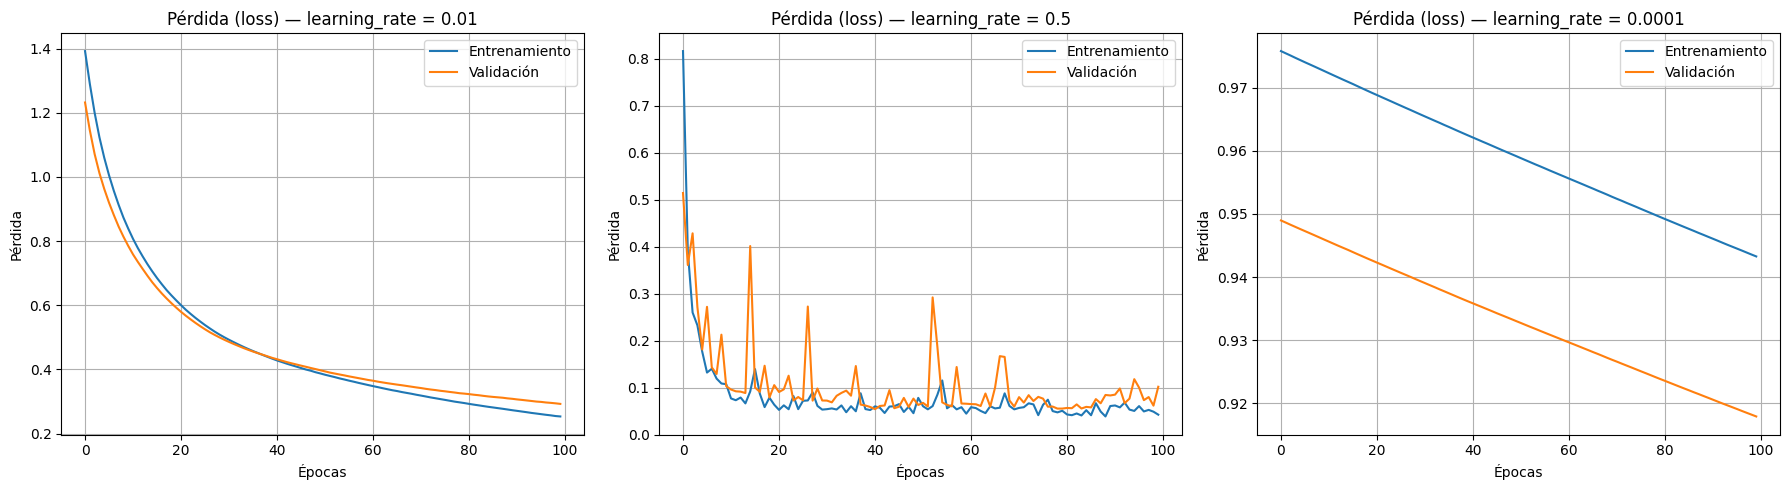

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lr in zip(axes, learning_rates):
    h = historiales[lr]
    ax.plot(h['loss'], label='Entrenamiento')
    ax.plot(h['val_loss'], label='Validación')
    ax.set_title(f'Pérdida (loss) — learning_rate = {lr}')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Pérdida')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

**Gráfica 1:**

learning_rate = 0.01

Observación: Vemos que tanto la pérdida de entrenamiento (línea azul) como la de validación (línea naranja) disminuyen de manera constante y relativamente suave a lo largo de las épocas. La pérdida de validación es ligeramente superior a la de entrenamiento, lo cual es normal. Al final, ambas curvas se estabilizan en valores bajos.

Interpretación: Esta es una curva de aprendizaje saludable. Indica que con learning_rate = 0.01, el modelo está aprendiendo de manera efectiva, convergiendo hacia un buen mínimo sin inestabilidades. El modelo está generalizando bien a los datos no vistos (validación), ya que la pérdida de validación sigue la misma tendencia que la de entrenamiento y no hay una gran divergencia entre ellas, lo que podría indicar sobreajuste.

**Gráfica 2:**

learning_rate = 0.5

Observación: Las curvas de pérdida son muy erráticas y oscilan salvajemente. La pérdida no disminuye de forma estable, sino que sube y baja bruscamente, incluso mostrando picos altos. Aunque al final la pérdida de validación parece ser muy baja (incluso 0.0451 en la salida), el comportamiento durante el entrenamiento es muy inestable.

Interpretación: Esto es un claro indicio de que el learning_rate es demasiado alto. El modelo está dando pasos tan grandes en el espacio de pesos que constantemente "salta" por encima del mínimo, sin poder asentarse en una solución estable. Aunque por casualidad pueda terminar en un punto bajo, el proceso es inestable y difícil de controlar. Este comportamiento concuerda con lo que explicamos anteriormente sobre un learning rate alto.

**Gráfica 3:**

learning_rate = 0.0001

Observación: Ambas curvas de pérdida (entrenamiento y validación) disminuyen, pero lo hacen de forma muy, muy lenta. Incluso después de 100 épocas, la pérdida sigue siendo relativamente alta y parece que aún está en proceso de disminuir, sin haber alcanzado una meseta o un mínimo claro.

Interpretación: Esto sugiere que el learning_rate es demasiado bajo. Los pasos que el modelo da para ajustar sus pesos son tan pequeños que el entrenamiento avanza a un ritmo extremadamente lento. El modelo está aprendiendo, pero necesitaría muchas más épocas (quizás miles) para alcanzar un nivel de pérdida similar al que logró con learning_rate = 0.01. Podría estar atrapado en una zona muy plana de la función de pérdida o simplemente no tiene suficiente "velocidad" para converger en el tiempo dado. Esto también concuerda con la explicación de un learning rate bajo.

**Gráficas de accuracy por learning rate**



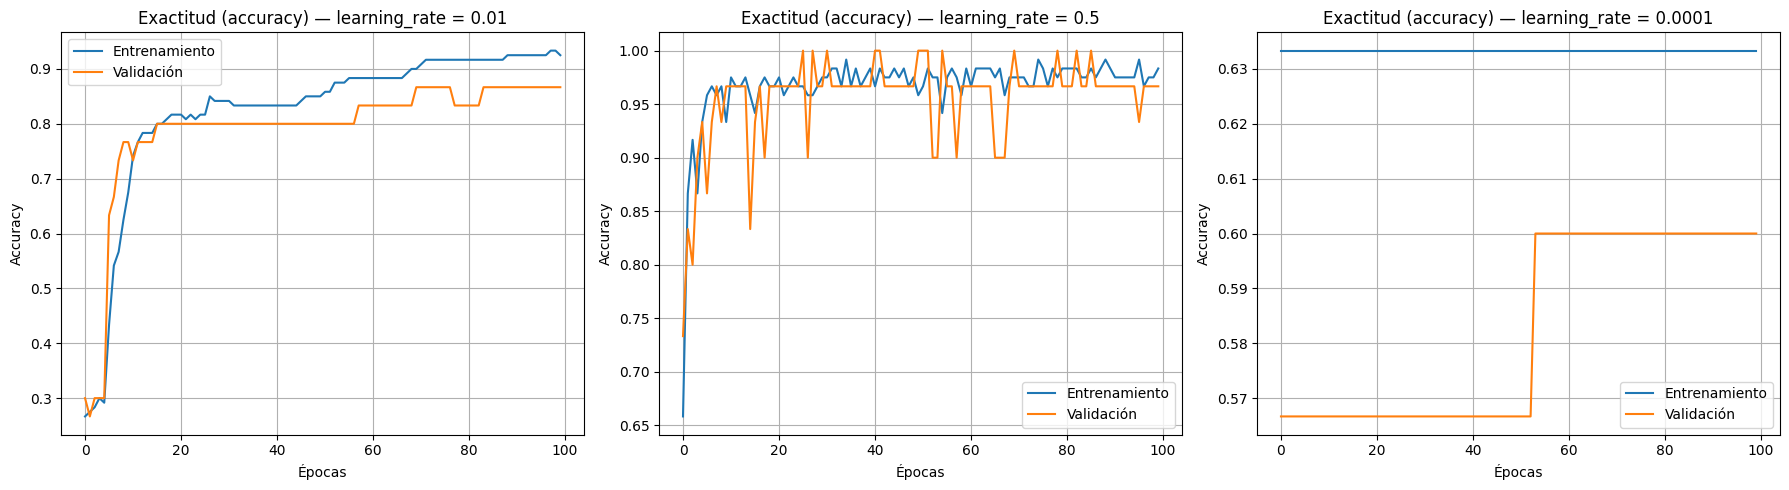

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lr in zip(axes, learning_rates):
    h = historiales[lr]
    ax.plot(h['accuracy'], label='Entrenamiento')
    ax.plot(h['val_accuracy'], label='Validación')
    ax.set_title(f'Exactitud (accuracy) — learning_rate = {lr}')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

**Gráfica 1:**

learning_rate = 0.01

Observación: Tanto la exactitud de entrenamiento (línea azul) como la de validación (línea naranja) aumentan de forma constante y suave, estabilizándose en valores altos (alrededor del 90-95% para entrenamiento y 85-90% para validación). Las curvas están muy cerca la una de la otra.

Interpretación: Esta es una señal muy positiva. Indica que con learning_rate = 0.01, el modelo está aprendiendo de manera efectiva a clasificar las flores, y lo más importante, está generalizando bien a datos que no ha visto durante el entrenamiento (conjunto de validación). La diferencia pequeña entre ambas exactitudes sugiere que no hay un sobreajuste significativo, y el modelo es robusto.

**Gráfica 2:**

learning_rate = 0.5

Observación: Las curvas de exactitud son muy erráticas y oscilantes, similar a lo que vimos con la pérdida. Al principio, la exactitud sube muy rápido e inestablemente, y puede llegar a valores altos (incluso casi el 100% en entrenamiento y validación al final). Sin embargo, el camino para llegar allí es muy irregular, con subidas y bajadas bruscas.

Interpretación: Un learning_rate demasiado alto provoca esta inestabilidad. Aunque el modelo pueda alcanzar una exactitud alta, el proceso de aprendizaje es caótico. Los pesos cambian demasiado en cada paso, y el modelo tiene dificultades para encontrar un mínimo estable. Podría "por casualidad" caer en un punto con alta exactitud al final, pero es un comportamiento poco fiable y no es indicativo de un proceso de entrenamiento controlado y robusto.

**Gráfica 3:**

learning_rate = 0.0001

Observación: Ambas curvas de exactitud (entrenamiento y validación) aumentan, pero lo hacen de forma extremadamente lenta. Incluso después de 100 épocas, la exactitud se mantiene en valores relativamente bajos (alrededor del 60-65%) y sigue una trayectoria ascendente muy gradual. No llega a valores altos como en el caso de 0.01.

Interpretación: Esto confirma que el learning_rate es demasiado bajo. El modelo está aprendiendo, pero los ajustes en sus pesos son tan pequeños que progresa a un ritmo muy lento. Necesitaría un número significativamente mayor de épocas para alcanzar un nivel de exactitud competitivo. Con 100 épocas, el modelo no ha tenido tiempo suficiente para aprender de manera efectiva con pasos tan diminutos.

## **Análisis crítico**

### 1. ¿En qué caso la pérdida converge de manera más estable?

Con learning_rate = 0.01 se observa la convergencia más estable de los tres casos. Tanto la pérdida de entrenamiento como la de validación disminuyen de manera constante y relativamente suave a lo largo de las 100 épocas, estabilizándose en valores bajos al final. La pérdida de validación es ligeramente superior a la de entrenamiento, lo cual es un comportamiento normal y no indica sobreajuste, ya que ambas curvas siguen la misma tendencia sin separarse significativamente. Este resultado confirma que 0.01 es un tamaño de paso adecuado: lo bastante grande para avanzar con eficiencia y lo bastante pequeño para no sobrepasar el mínimo de la función de pérdida.

### 2. ¿En cuál se observan oscilaciones o divergencia?

Con learning_rate = 0.5 se observaron oscilaciones marcadas y erráticas en la curva de pérdida, con picos altos y caídas bruscas a lo largo de todo el entrenamiento, en lugar de un descenso progresivo. Curiosamente, la pérdida de validación final fue muy baja (0.0451), lo que podría interpretarse a primera vista como un buen resultado; sin embargo, el camino recorrido para llegar allí fue completamente inestable. Esto evidencia que un valor final bajo no es sinónimo de un buen proceso de entrenamiento: el modelo estuvo "saltando" alrededor del mínimo durante la mayor parte del entrenamiento, y solo coincidió en un punto favorable al final, lo cual no es un comportamiento confiable ni reproducible con otros datos o inicializaciones de pesos.

### 3. ¿Qué learning rate permitió un entrenamiento más eficiente?

El learning_rate = 0.01 permitió el entrenamiento más eficiente en términos de estabilidad y calidad de la convergencia. Alcanzó una exactitud alta (aproximadamente 90-95% en entrenamiento y 85-90% en validación) de forma progresiva y sin oscilaciones. En contraste, aunque learning_rate = 0.5 llegó a una exactitud cercana al 100%, lo hizo mediante un proceso caótico y poco fiable; y learning_rate = 0.0001 se quedó estancado alrededor del 60-65% de exactitud tras 100 épocas, sin alcanzar aún un buen nivel de desempeño. Esto confirma que la eficiencia de un entrenamiento no depende solo del resultado final, sino también de la estabilidad y previsibilidad del proceso, criterios en los que 0.01 fue claramente superior.

### 4. ¿Cómo se evidencia el efecto del learning rate en la actualización de los pesos?

El efecto del learning rate se refleja directamente en la magnitud de los cambios que sufren los pesos en cada iteración, y esto se visualiza claramente en la forma de las curvas. Con learning_rate = 0.5, los pesos se actualizan con pasos demasiado grandes, generando curvas de pérdida y exactitud erráticas, con subidas y bajadas bruscas de una época a otra. Con learning_rate = 0.0001, los pesos apenas cambian en cada paso, lo que produce curvas casi planas que ascienden o descienden de forma extremadamente gradual, sin llegar a estabilizarse en 100 épocas. Con learning_rate = 0.01, los cambios en los pesos son proporcionales al error cometido, lo que se traduce en curvas suaves y consistentes, tanto de pérdida como de exactitud, evidenciando un ajuste controlado y efectivo de los parámetros del modelo.

### 5. ¿Cómo se relaciona la función de pérdida con la retropropagación del error?

La función de pérdida cuantifica qué tan lejos está la predicción del modelo respecto a la etiqueta real, y es precisamente ese valor el que la retropropagación utiliza como punto de partida para calcular los gradientes. A través de la regla de la cadena, la retropropagación distribuye el error medido por la función de pérdida hacia atrás, capa por capa, determinando cuánto contribuyó cada peso de la red a ese error total. En los tres experimentos realizados, este mecanismo fue el mismo; lo único que cambió fue el learning rate, que determina qué tan grande es el ajuste aplicado sobre esos gradientes calculados por backpropagation. Esto explica por qué, aunque la arquitectura y el mecanismo de cálculo del error fueron idénticos en los tres casos, el comportamiento del entrenamiento fue radicalmente distinto.

### 6. Compare el comportamiento de la pérdida y la exactitud. ¿Siempre evolucionan de la misma manera?

En general, la pérdida y la exactitud evolucionan de forma inversamente relacionada: a medida que la pérdida disminuye, la exactitud tiende a aumentar. Esto se observó claramente con learning_rate = 0.01, donde ambas métricas mejoraron de forma paralela y suave. Sin embargo, esta relación no siempre es simétrica ni perfectamente correlacionada, como lo evidenció el caso de learning_rate = 0.5: la exactitud logró subir hasta valores cercanos al 100% pese a que la curva de pérdida osciló de forma caótica durante todo el entrenamiento. Esto ocurre porque la exactitud es una métrica discreta (la predicción es correcta o no lo es), mientras que la pérdida es continua y sensible a la confianza de la predicción, incluso cuando la clase ya es correcta. Por eso, un modelo puede mostrar una exactitud aparentemente buena mientras su pérdida sigue siendo inestable o poco confiable, como ocurrió en el experimento con learning_rate = 0.5.

## Referencias

Galea, A., & Capelo, L. (2018). *Applied deep learning with Python: Use scikit-learn, TensorFlow, and Keras to create intelligent systems and machine learning solutions*. Packt Publishing.


Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.


Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems* (2nd ed.). O'Reilly Media.